In [ ]:

# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES
# TO THE CORRECT LOCATION (/kaggle/input) IN YOUR NOTEBOOK,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

import os
import sys
from tempfile import NamedTemporaryFile
from urllib.request import urlopen
from urllib.parse import unquote, urlparse
from urllib.error import HTTPError
from zipfile import ZipFile
import tarfile
import shutil

CHUNK_SIZE = 40960
DATA_SOURCE_MAPPING = 'brain-mri-images-for-brain-tumor-detection:https%3A%2F%2Fstorage.googleapis.com%2Fkaggle-data-sets%2F165566%2F377107%2Fbundle%2Farchive.zip%3FX-Goog-Algorithm%3DGOOG4-RSA-SHA256%26X-Goog-Credential%3Dgcp-kaggle-com%2540kaggle-161607.iam.gserviceaccount.com%252F20240629%252Fauto%252Fstorage%252Fgoog4_request%26X-Goog-Date%3D20240629T211357Z%26X-Goog-Expires%3D259200%26X-Goog-SignedHeaders%3Dhost%26X-Goog-Signature%3D1cbe9f70053e16bd745271219a479b4e7fd460a9aafdc0980cd241eaa4ac343d6d26bd561329c507d884b15cf40e11f2956ef99368f235f167bfde94ecae2b82993fce155b8cf5814b5d41ee80cbfb6caac9cad19e1590a0cd2d17b7a464080c2c37063c1b469ee26f572fdb28bf8594f1d5cd351ab509e6134813009766edd67db5c7a8a4cf77c670827d8b6fe64a4e3c17bdc551df75f1ed6c42b12e4449f208a112e077580c50a84ebb32d5227695d2c5a8b801bf23bb872174142d66464348dbe903eb459706f83b62b43096152b072ad553e10d47e0ff5b1fcc2052f8fd3d4c341c46ec95ed7a85f2e5c61bbcc56167e1481b3303d7b607b7482b48c051,fire-dataset:https%3A%2F%2Fstorage.googleapis.com%2Fkaggle-data-sets%2F529007%2F969357%2Fbundle%2Farchive.zip%3FX-Goog-Algorithm%3DGOOG4-RSA-SHA256%26X-Goog-Credential%3Dgcp-kaggle-com%2540kaggle-161607.iam.gserviceaccount.com%252F20240629%252Fauto%252Fstorage%252Fgoog4_request%26X-Goog-Date%3D20240629T211357Z%26X-Goog-Expires%3D259200%26X-Goog-SignedHeaders%3Dhost%26X-Goog-Signature%3D989f57af757019f0e2fcf68aaa403b020bde2bf468cf2e2a19436fbb0621863f495cf5cd284af6f50bd3a93572ed7326fb93388dc3d06010f8c0c198cb266d8db1fe135b40f08e6a9addb512ddfaaa43dbc83f4c7034e3d99158dde653c557c86f010d99438791220aa41bcd0c452bfa85bd151ed929a31266e5b33035ea5378e5e578060f640b8ed5e354ebefcf677b4286b27ab360a5352d5a2ac7b38ecd08cccd750d1ad758622ac6277111707dd36c724cab20d4f8402c63d7db1d469736ede27bcec733e7d171dc1866f6f16f539f110cc98ca96fdbf9f2558397e15d799af1d55ac32f14d8a91746d4e7a14643b5c600f49a5f07c667079bb6044e85be,brainn:https%3A%2F%2Fstorage.googleapis.com%2Fkaggle-data-sets%2F5306172%2F8820143%2Fbundle%2Farchive.zip%3FX-Goog-Algorithm%3DGOOG4-RSA-SHA256%26X-Goog-Credential%3Dgcp-kaggle-com%2540kaggle-161607.iam.gserviceaccount.com%252F20240629%252Fauto%252Fstorage%252Fgoog4_request%26X-Goog-Date%3D20240629T211357Z%26X-Goog-Expires%3D259200%26X-Goog-SignedHeaders%3Dhost%26X-Goog-Signature%3D5a7d959b00b09439d340b1981c23a793f294e1a16e37f24d4303e0d0a51b7ab6abea7588d9df277743bef8d29bdcad15bebdb056dfaa65ba6fc084e93037844a4cb9e77c16cce42e1a902a7a4b772d8b5f54d9178b7938753c1e5ce10bf2973116f35fa5a8b0f65a1c8094f512a03ad4fa0fcb0b28e4e7fa299636fe19740ad1f53780d9f6d10aee61908c44b77359a7bcc4b82b21a87ae6404cca107c7808f36d8f58ceddc348a59440a3493524fdb7c8cd98c59d982260350b7f55c2eac3223fb1c35cb86159afadd0c3f747178366624bbc74c43f909ecf5083a2af6bf3a92c7c12c096ff1387fd81edd31040fb6da4b8af0d97a686331a8956ab6e1db234'

KAGGLE_INPUT_PATH='/kaggle/input'
KAGGLE_WORKING_PATH='/kaggle/working'
KAGGLE_SYMLINK='kaggle'

!umount /kaggle/input/ 2> /dev/null
shutil.rmtree('/kaggle/input', ignore_errors=True)
os.makedirs(KAGGLE_INPUT_PATH, 0o777, exist_ok=True)
os.makedirs(KAGGLE_WORKING_PATH, 0o777, exist_ok=True)

try:
  os.symlink(KAGGLE_INPUT_PATH, os.path.join("..", 'input'), target_is_directory=True)
except FileExistsError:
  pass
try:
  os.symlink(KAGGLE_WORKING_PATH, os.path.join("..", 'working'), target_is_directory=True)
except FileExistsError:
  pass

for data_source_mapping in DATA_SOURCE_MAPPING.split(','):
    directory, download_url_encoded = data_source_mapping.split(':')
    download_url = unquote(download_url_encoded)
    filename = urlparse(download_url).path
    destination_path = os.path.join(KAGGLE_INPUT_PATH, directory)
    try:
        with urlopen(download_url) as fileres, NamedTemporaryFile() as tfile:
            total_length = fileres.headers['content-length']
            print(f'Downloading {directory}, {total_length} bytes compressed')
            dl = 0
            data = fileres.read(CHUNK_SIZE)
            while len(data) > 0:
                dl += len(data)
                tfile.write(data)
                done = int(50 * dl / int(total_length))
                sys.stdout.write(f"\r[{'=' * done}{' ' * (50-done)}] {dl} bytes downloaded")
                sys.stdout.flush()
                data = fileres.read(CHUNK_SIZE)
            if filename.endswith('.zip'):
              with ZipFile(tfile) as zfile:
                zfile.extractall(destination_path)
            else:
              with tarfile.open(tfile.name) as tarfile:
                tarfile.extractall(destination_path)
            print(f'\nDownloaded and uncompressed: {directory}')
    except HTTPError as e:
        print(f'Failed to load (likely expired) {download_url} to path {destination_path}')
        continue
    except OSError as e:
        print(f'Failed to load {download_url} to path {destination_path}')
        continue

print('Data source import complete.')


In [ ]:
from torchvision import datasets, transforms

In [ ]:
transform = transforms.Compose([
    transforms.Resize((120,120)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])
dataset = datasets.ImageFolder(root = '/kaggle/input/brainn/brain_tumor_dataset', transform = transform)
class_names = dataset.classes

In [ ]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([
    Conv2D(100, (3, 3), strides=(1, 1), padding='same', activation='relu', input_shape=(120, 120, 3)),
    MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),
    Conv2D(50, (3, 3), strides=(1, 1), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),
    Flatten(),
    Dense(50, activation='relu'),
    Dense(10, activation='relu'),
    Dense(2, activation='softmax')  # Adjust for binary classification
])


In [ ]:
from keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    '/kaggle/input/brainn/brain_tumor_dataset',
    target_size=(120, 120),
    batch_size=32,
    class_mode='categorical'  # Adjust for your classification type
)

validation_generator = test_datagen.flow_from_directory(
    '/kaggle/input/brainn/brain_tumor_dataset',
    target_size=(120, 120),
    batch_size=32,
    class_mode='categorical'  # Adjust for your classification type
)


Found 253 images belonging to 2 classes.
Found 253 images belonging to 2 classes.


In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs= 10,
    validation_data=validation_generator,
    validation_steps=len(validation_generator)
)


Epoch 1/10
8/8 [==============================] - 11s 1s/step - loss: 0.5643 - accuracy: 0.7273 - val_loss: 0.4994 - val_accuracy: 0.7826
Epoch 2/10
8/8 [==============================] - 11s 1s/step - loss: 0.5539 - accuracy: 0.7273 - val_loss: 0.4693 - val_accuracy: 0.7826
Epoch 3/10
8/8 [==============================] - 11s 1s/step - loss: 0.5337 - accuracy: 0.7510 - val_loss: 0.4582 - val_accuracy: 0.7787
Epoch 4/10
8/8 [==============================] - 11s 1s/step - loss: 0.5370 - accuracy: 0.7431 - val_loss: 0.4402 - val_accuracy: 0.8182
Epoch 5/10
8/8 [==============================] - 11s 1s/step - loss: 0.4468 - accuracy: 0.8221 - val_loss: 0.3889 - val_accuracy: 0.8419
Epoch 6/10
8/8 [==============================] - 11s 1s/step - loss: 0.4406 - accuracy: 0.8024 - val_loss: 0.3831 - val_accuracy: 0.8379
Epoch 7/10
8/8 [==============================] - 11s 1s/step - loss: 0.4246 - accuracy: 0.8261 - val_loss: 0.4421 - val_accuracy: 0.7945
Epoch 8/10
8/8 [==================

In [ ]:
test_loss, test_accuracy = model.evaluate(validation_generator, steps=len(validation_generator))
print(f"Test Loss: {test_loss}, Test Accuracy: {test_accuracy}")


8/8 [==============================] - 3s 363ms/step - loss: 0.3021 - accuracy: 0.8893
Test Loss: 0.30207163095474243, Test Accuracy: 0.8893280625343323


In [ ]:
import numpy as np
from keras.preprocessing import image

img_path = '/kaggle/input/brainn/brain_tumor_dataset/yes/Y108.jpg'
img = image.load_img(img_path, target_size=(120, 120))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array /= 255.0  # Rescale to [0, 1]

predicted_class = model.predict(img_array)
print(predicted_class)
if(predicted_class[0][1]>predicted_class[0][0]):
    index = 1
else:
    index = 0
print(class_names[index])

[[0.11739103 0.882609  ]]
yes


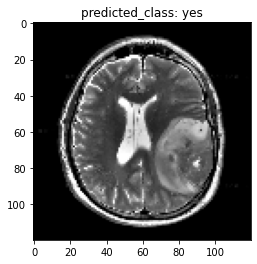

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(img)
plt.title(f'predicted_class: {class_names[index]}')
plt.show()